In [2]:
import qiskit
import numpy as np
import matplotlib

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_bloch_multivector,plot_histogram
from qiskit_aer import AerSimulator

In [3]:
qc = QuantumCircuit(4,2)
qc.h(0)
qc.h(2)

qc.cx(0,1)
qc.cx(2,3)


In [4]:
qc.cx(0,2)
qc.cx(1,3)

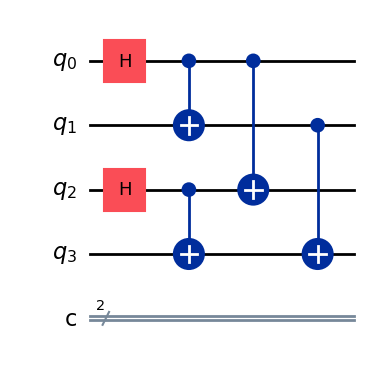

In [5]:
qc.draw('mpl')

## Python Calculation

In [ ]:
# 3차원 기저 벡터 (qutrit basis) |0>, |1>, |2> 정의
ket0 = np.array([1, 0, 0])
ket1 = np.array([0, 1, 0])
ket2 = np.array([0, 0, 1])

def makesig(i, j):
    """ |ij><ij| 형태의 9x9 프로젝터 행렬을 만듭니다. i, j는 0, 1, 2 사용. """
    # 두 큐트리트의 기저 벡터 |i>와 |j>
    ket_i = basis[i]
    ket_j = basis[j]
    # 텐서곱으로 9차원 기저 벡터 |ij> 생성
    ket_ij = np.kron(ket_i, ket_j)
    # 외적(outer product)을 통해 프로젝터 |ij><ij| 계산
    projector = np.outer(ket_ij, np.conj(ket_ij))
    return projector

# makesig 함수에서 사용할 basis 리스트
basis = [ket0, ket1, ket2]

# --- 논문의 (2)번 식: sigma_plus, sigma_minus 정의 ---
# (Mathematica의 1,2,3 인덱스를 Python의 0,1,2 인덱스로 변환)
sigma_plus = (1/3) * (makesig(0, 1) + makesig(1, 2) + makesig(2, 0))
sigma_minus = (1/3) * (makesig(1, 0) + makesig(2, 1) + makesig(0, 2))

# --- 최대 얽힘 상태 |Ψ+><Ψ+| 정의 ---
# |Ψ+> = 1/sqrt(3) * (|00> + |11> + |22>)
psi_plus_vec = (np.kron(ket0, ket0) + np.kron(ket1, ket1) + np.kron(ket2, ket2)) / np.sqrt(3)
max_entangled_proj = np.outer(psi_plus_vec, np.conj(psi_plus_vec))

# --- 파라미터 설정 ---
F = 0.7  # 예시 피델리티 값
alpha = 3.5 # 예시 알파 값 (속박 얽힘 영역: 3 < alpha <= 4)

# --- 논문의 (3)번 식: rho_free 정의 ---
rho_free = F * max_entangled_proj + (1 - F) * sigma_plus

# --- 논문의 (4)번 식: sigma_alpha 정의 ---
sigma_alpha = (2/7) * max_entangled_proj + (alpha/7) * sigma_plus + ((5 - al여pha)/7) * sigma_minus

# --- 결과 확인 (옵션) ---
#print("rho_free (3)번 식:")
print(np.round(rho_free, 3)) # 행렬이 크므로 필요시 주석 해제하여 확인
#print("Trace of rho_free:", np.trace(rho_free))


#print("\nsigma_alpha (4)번 식:")
print(np.round(sigma_alpha, 3)) # 행렬이 크므로 필요시 주석 해제하여 확인
#print("Trace of sigma_alpha:", np.trace(sigma_alpha))

[[0.233 0.    0.    0.    0.233 0.    0.    0.    0.233]
 [0.    0.1   0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.233 0.    0.    0.    0.233 0.    0.    0.    0.233]
 [0.    0.    0.    0.    0.    0.1   0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.1   0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.233 0.    0.    0.    0.233 0.    0.    0.    0.233]]
[[0.095 0.    0.    0.    0.095 0.    0.    0.    0.095]
 [0.    0.167 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.071 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.071 0.    0.    0.    0.    0.   ]
 [0.095 0.    0.    0.    0.095 0.    0.    0.    0.095]
 [0.    0.    0.    0.    0.    0.167 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.167 0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.071 0.   ]
 [0.095 0.    0.    0.    0.09